# Analysis of a Given Dataset

The objective of this project is to solve a typical data analysis problem using various tools, in order to assess the understanding and correct application of the tools and techniques studied.

## Problem Statement

This project will use a dataset of trips made by the New York City Taxi service.

Each item to be solved will be placed in a separate section, followed by the cell where the corresponding code for its solution will be placed.

Additional cells may be added for the sake of clarity in the approach or to show intermediate results.

### Initial Setup and Data Load

In [1]:
import seaborn as sns
import pandas as pd
sns.set(style='darkgrid')

"""
DO NOT MODIFY THIS LINES. THEY ARE THE RESPONSABLES TO UPLOAD THE DATA, 
TO REALISE THE ANALISIS
"""
df = sns.load_dataset("taxis")
df['date'] = df['pickup'].dt.date # Column only with date, without hours
df['hour_pickup'] = df['pickup'].dt.time
df['hour_dropoff'] = df['dropoff'].dt.time
df['duration'] = df['dropoff']-df['pickup']

In [2]:
""""
    'pickup':'fecha_hora_subida',
    'dropoff':'fecha_hora_bajada',
    'passengers':'pasajeros',
    'distance':'distancia',
    'fare':'tarifa',
    'tip':'propina',
    'tolls':'peajes',
    'payment':'pago',
    'pickup_zone':'zona_subida',
    'dropoff_zone':'zona_bajada',
    'pickup_borough':'barrio_subida',
    'dropoff_borough':'barrio_bajada'})
"""""

'"\n    \'pickup\':\'fecha_hora_subida\',\n    \'dropoff\':\'fecha_hora_bajada\',\n    \'passengers\':\'pasajeros\',\n    \'distance\':\'distancia\',\n    \'fare\':\'tarifa\',\n    \'tip\':\'propina\',\n    \'tolls\':\'peajes\',\n    \'payment\':\'pago\',\n    \'pickup_zone\':\'zona_subida\',\n    \'dropoff_zone\':\'zona_bajada\',\n    \'pickup_borough\':\'barrio_subida\',\n    \'dropoff_borough\':\'barrio_bajada\'})\n'

In [3]:
# df['pickup_borough'].unique()
#df.info()
# df.describe()
df.head(5)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,date,hour_pickup,hour_dropoff,duration
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,2019-03-23,20:21:09,20:27:24,0 days 00:06:15
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,2019-03-04,16:11:55,16:19:00,0 days 00:07:05
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,2019-03-27,17:53:01,18:00:25,0 days 00:07:24
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,2019-03-10,01:23:59,01:49:51,0 days 00:25:52
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,2019-03-30,13:27:42,13:37:14,0 days 00:09:32


### Dataset Overview and Descriptive Statistics

In [4]:
# Place the code below this comment
'''
Initial observations:
- The dataset contains passenger counts per trip. It's currently unclear if there's a correlation between the number of passengers and the tip amount.
- Trips appear to be short, based on the low mileage and the maximum trip duration.
'''

# This brief interpretation is based on:
df.describe()


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,duration
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000,6433
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794,0 days 00:14:20.976993626
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000,0 days 00:00:00
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000,0 days 00:06:30
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000,0 days 00:10:54
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000,0 days 00:18:31
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000,0 days 01:47:40
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570,0 days 00:11:38.633516153


### Trips per Taxi Type

The city has two types of taxis (yellow, green). Calculate the number of trips made for each type. Plot the results.

color
green      982
yellow    5451
Name: passengers, dtype: int64


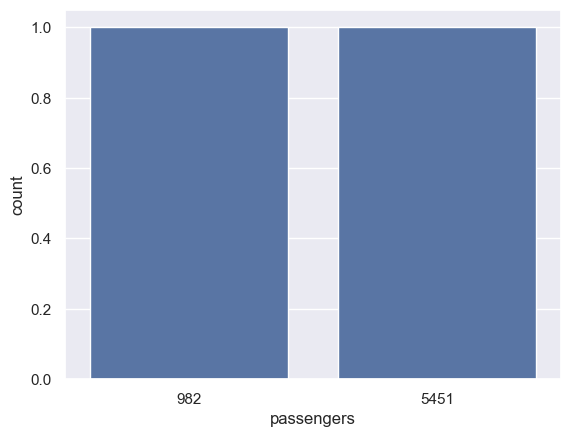

In [5]:
# Calculate and plot the total trips for each taxi type.
colortype = df.groupby(["color"])["passengers"].count()
print(colortype)
sb = sns.countplot(x=colortype)

color
green      982
yellow    5451
Name: passengers, dtype: int64


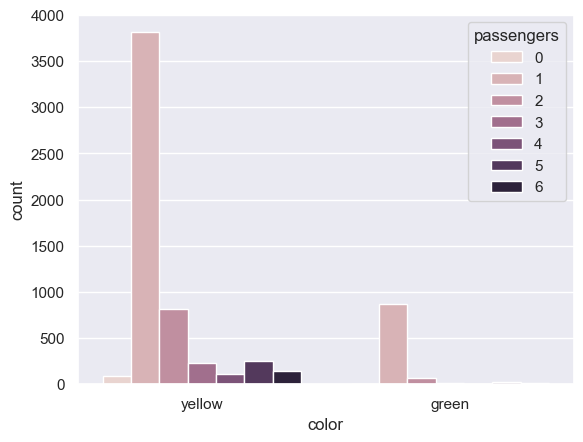

In [6]:
# Alternative plot: Trip count by number of passengers.

colortype = df.groupby(["color"])["passengers"].count()
print(colortype)
sb = sns.countplot(x="color", hue= "passengers", data=df)

### Otros indicadores, por tipo de Taxi

Indicar cual es la distancia promedio, la tarifa máxima, mínima y promedio de cada tipo de Taxi.

In [8]:
# Average distance
average_distance = pd.DataFrame(df.groupby(by='color')['distance'].mean())
print(round(average_distance, 2))
print("---------------------------")
# Maximum fare
max_fare = pd.DataFrame(df.groupby(by='color')['fare'].max())
print(max_fare)
print("---------------------------")
# Minimum fare
min_fare = pd.DataFrame(df.groupby(by='color')['fare'].min())
print(min_fare)
# Average stats for each taxi type
print("---------------------------")
numeric_cols = df.select_dtypes(include='number').columns
mean_by_type = pd.DataFrame(df.groupby(by='color')[numeric_cols].mean())
print(round(mean_by_type, 2))
print("---------------------------")

        distance
color           
green       3.41
yellow      2.96
---------------------------
         fare
color        
green   150.0
yellow  150.0
---------------------------
        fare
color       
green    2.5
yellow   1.0
---------------------------
        passengers  distance   fare   tip  tolls  total  \
color                                                     
green         1.25      3.41  14.04  0.80   0.28  16.48   
yellow        1.59      2.96  12.92  2.19   0.33  18.88   

                        duration  
color                             
green  0 days 00:15:37.134419551  
yellow 0 days 00:14:07.257200513  
---------------------------


### Payment Types

Determine the most common payment type and calculate the average amount charged for each, using the `total` column.

In [ ]:
# Most used payment type
print("---------------------------")
payment_type_counts = df.groupby(by='payment')['passengers'].count()
print(payment_type_counts)
print("This shows the total count of transactions for each payment type, revealing the most used one.")
print("---------------------------")
# Average amount (from the "total" column) for each payment type
avg_total_by_payment = df.groupby(by='payment')['total'].mean()
print(round(avg_total_by_payment, 2))

---------------------------
payment
cash           1812
credit card    4577
Name: passengers, dtype: int64
This shows the total count of transactions for each payment type, revealing the most used one.
---------------------------
payment
cash           14.68
credit card    20.07
Name: total, dtype: float64


### Pickups and Dropoffs

Calculate the number of trips per pickup city (pickup_borough) and pickup zone (pickup_zone).

Determine the number of trips that occur within the same neighborhood versus those that occur between different neighborhoods.

In [ ]:
print("Trips by Pickup Borough")
print("---------------------------")
pickup_borough_counts = df.groupby(by='pickup_borough')['passengers'].count()
print(pickup_borough_counts)
print("---------------------------")
print("Trips by Pickup Zone")
pickup_zone_counts = df.groupby(by='pickup_zone')['passengers'].count()
print(pickup_zone_counts)
print("---------------------------")
print("Total trips within the same borough")
# Filter for trips where pickup_borough == dropoff_borough
intra_borough_trips = df[df['pickup_borough'] == df['dropoff_borough']]
intra_borough_trips = intra_borough_trips.groupby('pickup_borough')['passengers'].count()
print(intra_borough_trips)
print("---------------------------")
# Total trips between different boroughs
inter_borough_trips = df[df['pickup_borough'] != df['dropoff_borough']]
inter_borough_counts = inter_borough_trips.groupby('pickup_borough')['passengers'].count()
print(f"The total number of trips between different boroughs is: {sum(inter_borough_counts)}")

Trips by Pickup Borough
---------------------------
pickup_borough
Bronx          99
Brooklyn      383
Manhattan    5268
Queens        657
Name: passengers, dtype: int64
---------------------------
Trips by Pickup Zone
pickup_zone
Allerton/Pelham Gardens      2
Alphabet City                9
Astoria                     65
Auburndale                   1
Battery Park                 1
                          ... 
Woodlawn/Wakefield           1
Woodside                    26
World Trade Center          24
Yorkville East              71
Yorkville West             102
Name: passengers, Length: 194, dtype: int64
---------------------------
Total trips within the same borough
pickup_borough
Bronx          66
Brooklyn      282
Manhattan    4885
Queens        349
Name: passengers, dtype: int64
---------------------------
The total number of trips between different boroughs is: 825


### Daily Trip Cycle Analysis

Create a visualization to show how the number of trips varies over a 24-hour cycle, based on the hour_pickup column.

<Axes: xlabel='hour', ylabel='count'>

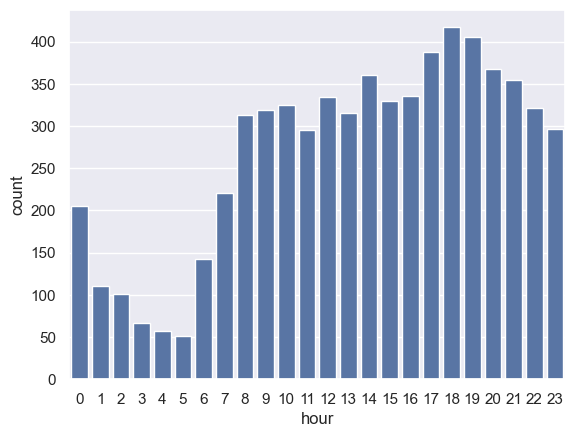

In [ ]:
# Plot hourly trip distribution ("hour_pickup" column).

df["hour"] = pd.to_datetime(df["pickup"]).dt.hour
sns.countplot(x="hour", data=df)

### Daily Revenue Analysis

Create a visualization to show the trend of total daily billing over the entire period. The data should be plotted against time, with the dates in ascending order.

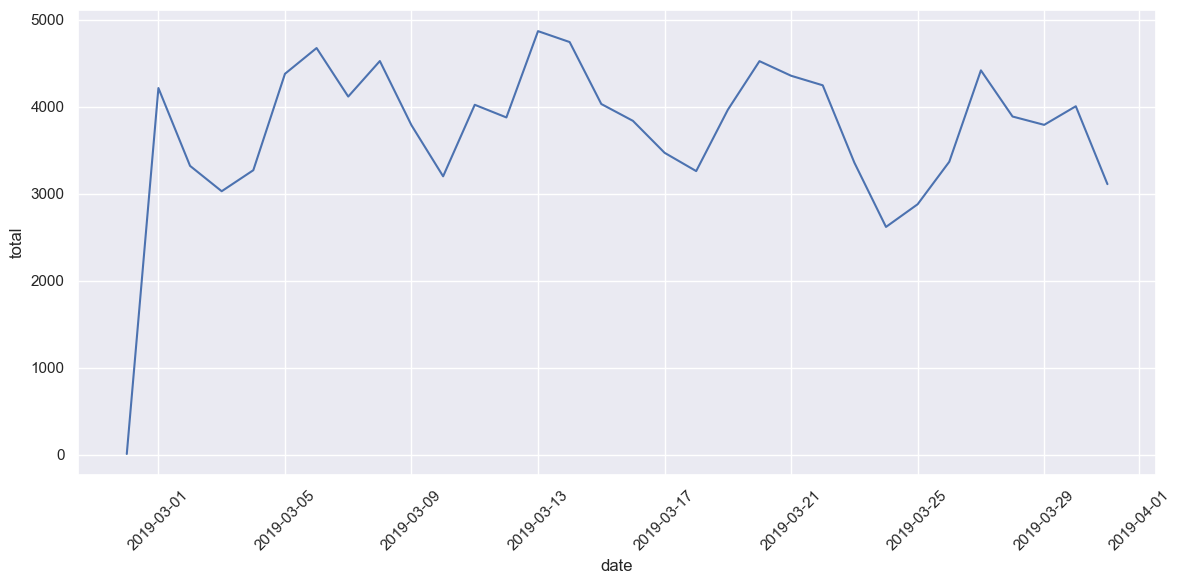

In [14]:
# Plot the evolution of daily revenue over time.
# Data is aggregated by day and sorted chronologically (ascending dates).

import matplotlib.pyplot as plt

orderBy = df.groupby('date')['total'].sum().reset_index().sort_values('date')

plt.figure(figsize=(12,6))
sns.lineplot(x="date", y="total", data=orderBy)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cost Per Mile in Manhattan

Calculate the average fare per mile for trips that took place in Manhattan.

In [15]:
# Average cost per mile in Manhattan
# Formula: fare / miles = cost_per_mile

prom = df.loc[
    (df['pickup_borough'] == 'Manhattan')
    &
    (df['dropoff_borough'] == 'Manhattan')
    &
    (df['fare'] >= 0.1)
    &
    (df['distance'] >= 0.1)
]['fare'].mean()

print(f"The average cost per mile in Manhattan is ${round(prom, 2)}")

The average cost per mile in Manhattan is $9.71


### The Best Zones for High Tips

In which zone should a taxi operate to have the best chances of receiving high tips? (Use the `pickup_zone` column).

In [ ]:
# Zone with the highest tips ("pickup_zone")
avg_tip_by_zone = df.groupby("pickup_zone")["tip"].mean()
top_5_zones = pd.DataFrame(avg_tip_by_zone.sort_values(ascending=False).head(5))
print(top_5_zones)

                                    tip
pickup_zone                            
Flushing Meadows-Corona Park  10.000000
Bronx Park                     8.390000
JFK Airport                    5.760927
LaGuardia Airport              5.664041
South Ozone Park               5.530000


### But Only During the Day...

Refine the previous analysis, considering that the driver only wants to work between 8:00 and 16:00 (8 AM - 4 PM). Does the same zone remain the best, or should they work in a different one?

In [ ]:
# Best tipping zone for the day shift (8 AM - 4 PM).
# df[df["B"] > 5].groupby("A")

df2 = df[(df["hour"] > 8) & (df["hour"] < 16)].groupby("pickup_zone")["tip"].mean()
df3 = pd.DataFrame(df2.sort_values(ascending=False).head(5))

print("First, let's review the top 5 tipping locations from the overall analysis:")
print(round(top_5_zones, 2))
print("----------------------")
print("Now, let's look at the top 5 locations specifically for the 8 AM to 4 PM shift:")
print(round(df3, 2))
print("----------------------")
print("This indicates that it is more profitable for a driver to work in different zones during these hours.")

First, let's review the top 5 tipping locations from the overall analysis:
                                tip
pickup_zone                        
Flushing Meadows-Corona Park  10.00
Bronx Park                     8.39
JFK Airport                    5.76
LaGuardia Airport              5.66
South Ozone Park               5.53
----------------------
Now, let's look at the top 5 locations specifically for the 8 AM to 4 PM shift:
                                tip
pickup_zone                        
LaGuardia Airport              6.24
DUMBO/Vinegar Hill             5.37
JFK Airport                    4.90
Long Island City/Queens Plaza  4.72
Two Bridges/Seward Park        4.32
----------------------
This indicates that it is more profitable for a driver to work in different zones during these hours.


### Correlation Analysis

Create a correlation matrix for the following variables:

*   Passengers
*   Distance
*   Fare
*   Tip

What insights can be gathered from the resulting visualization?

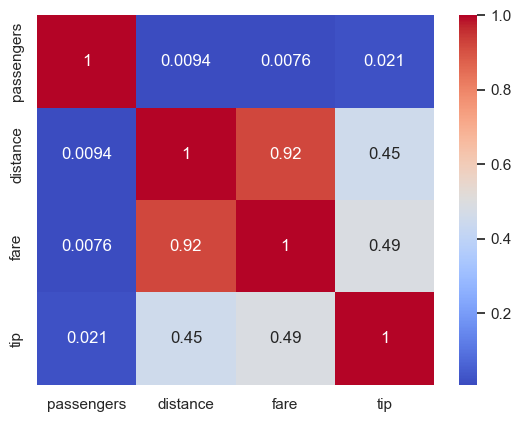

In [16]:

dfGraphic = ["passengers", "distance", "fare", "tip"]
correlation = df[dfGraphic].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()
#We can draw several conclusions. For example:

# - The tip amount is more strongly correlated with the fare and distance than with the number of passengers. This suggests that a higher fare, not more passengers, is the primary driver of a larger tip.
# - It can also be observed that passengers might save money by traveling in groups on longer trips (implying cost-splitting).